In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
import mesa

from model import SocialGPModel
from rewards import (
    sample_children_with_corr,
    make_parent_and_children_cholesky2,
    build_corr_matrix_option1,
    build_corr_matrix_option2,
    build_corr_matrix_option3,
    _min_max,
)
from tqdm import tqdm

In [3]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [4]:
rho_variants_raw = {
    "perfectly_calibrated":  np.array([1.0,  0.6,  0.0,  -0.6]), # beliefs match the true environment
    "sign_flipped":          np.array([1.0, -0.6,  0.0,  0.6]),  # trusts the anti-correlated peer and avoids the helpful one
    "socially_agnostic":     np.array([1.0,  0.0,  0.0,  0.0]),  # ignores all social information
    "uniform_over_trusting": np.array([1.0,  0.6,  0.6,  0.6]),  # assumes everyone is positively aligned (over-generalization)
    "uniform_distrusting":   np.array([1.0, -0.6, -0.6,  -0.6]), # assumes everyone is anti-correlated (over-avoidance)
    "overconfident":         np.array([1.0,  0.9,  0.0,  -0.9]), # right signs, inflated strength; tests sensitivity to overconfidence
    "underconfident":        np.array([1.0,  0.2,  0.0,  -0.2]), # right signs, damped strength; tests robustness to weak beliefs
    "selective_trust":       np.array([1.0,  0.6,  0.0,  0.0]),  # trusts only the truly helpful peer; ignores the harmful one
    "selective_avoidance":   np.array([1.0,  0.0,  0.0,  -0.6]), # avoids only the harmful peer; ignores the helpful one
}

def project_rho_to_pd(rho_vec, max_norm=0.99):
    """Ensure the hub-correlation matrix stays PD by capping ‖rho_social‖₂."""
    rho_vec = np.asarray(rho_vec, dtype=float)
    social = rho_vec[1:]
    norm = np.linalg.norm(social)
    if norm >= max_norm and norm > 0:
        rho_vec[1:] = social * (max_norm / norm)
    return rho_vec

rho_variants = {name: project_rho_to_pd(v) for name, v in rho_variants_raw.items()}
rho_list = list(rho_variants.values())
rho_label_lookup = {tuple(v.round(6)): name for name, v in rho_variants.items()}

def label_rho(rho_arr):
    """Map a rho array to its scenario name; returns 'unknown' if not in the table."""
    key = tuple(np.asarray(rho_arr).round(6))  # tolerate float repr differences
    return rho_label_lookup.get(key, "unknown")

## Plot correlations

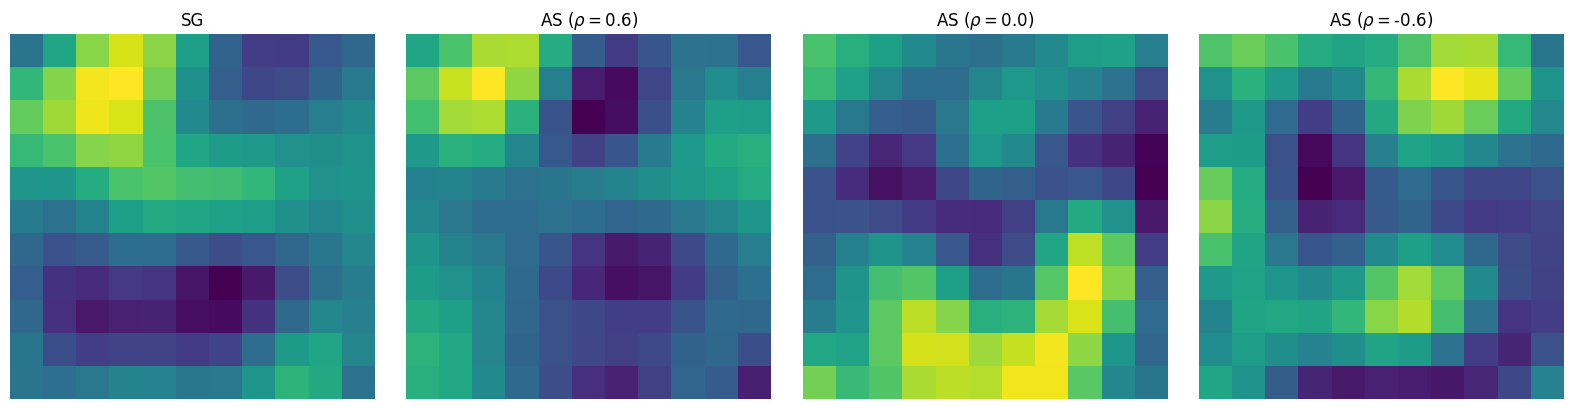

In [5]:
corr_matrix = build_corr_matrix_option1()  # parent + 3 children
n_children = corr_matrix.shape[0] - 1

seed = 0
a_rng = np.random.default_rng(seed)

grid_size = 11 # change resolution
parent, child_maps = make_parent_and_children_cholesky2(
    rng=a_rng,
    grid_size=grid_size,
    n_children=n_children + 1,
    length_scale=2.0,
    corr_matrix=corr_matrix,
)

# keep reward scale consistent with other sims
child_maps = [_min_max(c) - 0.5 for c in child_maps]

fig, axes = plt.subplots(1, len(child_maps) + 1, figsize=(4 * (len(child_maps) + 1), 4))

# parent
axes[0].imshow(_min_max(parent) - 0.5, origin='lower')
axes[0].set_title("SG")
axes[0].axis('off')

# children
for _corr, c, ax in zip([0.6, 0.0, -0.6], child_maps, axes[1:]):
    ax.imshow(c, origin='lower')
    ax.set_title(fr"AS ($\rho=${_corr})")
    ax.axis('off')

plt.tight_layout()
plt.show()

## Run the model

In [6]:
m = SocialGPModel(
    n=n_children + 1,
    model_type="SG-ICM",
    child_maps=[parent] + child_maps,
    network_type="directed_one_to_four",
    rho=np.array([1.0, 0.6, 0.0, -0.6]),
    tau_sampling=True, # tau=0.03,
)

for _ in range(15):
    m.step()

results = m.datacollector.get_agent_vars_dataframe()

results.head(20)

choice    reward  cumulative_reward model_type       tau
Step AgentID                                                            
1    1          (6, 0)  0.647405           0.647405     SG-ICM  0.028507
     2          (6, 8)  0.040471           0.040471         AS  0.028507
     3         (1, 10) -0.167882          -0.167882         AS  0.028507
     4          (4, 3) -0.219964          -0.219964         AS  0.028507
2    1          (4, 3)  0.039501           0.186906     SG-ICM  0.028507
     2          (7, 3) -0.022195          -0.481724         AS  0.028507
     3          (3, 4)  0.082054          -0.585828         AS  0.028507
     4         (10, 3)  0.121165          -0.598799         AS  0.028507
3    1         (10, 1)  0.948149           0.635055     SG-ICM  0.028507
     2          (2, 4) -0.222378          -1.204101         AS  0.028507
     3          (9, 3) -0.140959          -1.226787         AS  0.028507
     4          (3, 8) -0.028274          -1.127073         AS  0.028507
4    1         (10, 9) -0.323099          -0.188044     SG-ICM  0.028507
     2         (2, 10) -0.184389          -1.888490         AS  0.028507
     3         (9, 10) -0.254738          -1.981525         AS  0.028507
     4         (9, 10)  0.016741          -1.610332         AS  0.028507
5    1          (9, 1)  1.842158           1.154114     SG-ICM  0.028507
     2        (10, 10) -0.228761          -2.617252         AS  0.028507
     3          (0, 0)  0.313939          -2.167586         AS  0.028507
     4          (0, 1)  0.028823          -2.081509         AS  0.028507

In [7]:
R = build_corr_matrix_option1()

param_grid = {
    "n": 4,
    "model_type": "SG-ICM",
    "observation_noise_private": 0.0001,
    "observation_noise_social":  0.0001,
    "length_scale_private": 1.11,
    "beta_private": 0.33,
    "beta_social": 0.33,
    "tau_sampling": True,
    "seed": list(range(1000)),
    "network_type": "directed_one_to_four",
    "rho": rho_list,
    "corr_matrix": [R]
}

batch_results = mesa.batch_run(
    SocialGPModel,
    parameters=param_grid,
    iterations=1,
    max_steps=15,
    number_processes=None,
    data_collection_period=1,
    display_progress=True,
)

batch_results = pd.DataFrame(batch_results)

  0%|          | 0/9000 [00:00<?, ?it/s]

In [8]:
batch_results.head()

,RunId,iteration,Step,n,model_type,observation_noise_private,observation_noise_social,length_scale_private,beta_private,beta_social,tau_sampling,seed,network_type,rho,corr_matrix,avg_cumulative_reward,avg_reward,AgentID,choice,reward,cumulative_reward,tau
0,1,0,0,4,SG-ICM,0.0001,0.0001,1.11,0.33,0.33,True,0,directed_one_to_four,"[1.0, -0.6, 0.0, 0.6]","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",0.450503,0.450503,NaN,NaN,NaN,NaN,NaN
1,1,0,1,4,SG-ICM,0.0001,0.0001,1.11,0.33,0.33,True,0,directed_one_to_four,"[1.0, -0.6, 0.0, 0.6]","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",0.962854,0.481427,1.0,"(9, 9)",0.454154,0.454154,0.012208
2,1,0,1,4,AS,0.0001,0.0001,1.11,0.33,0.33,True,0,directed_one_to_four,"[1.0, -0.6, 0.0, 0.6]","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",0.962854,0.481427,2.0,"(5, 4)",0.432268,0.432268,0.012208
3,1,0,1,4,AS,0.0001,0.0001,1.11,0.33,0.33,True,0,directed_one_to_four,"[1.0, -0.6, 0.0, 0.6]","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",0.962854,0.481427,3.0,"(9, 8)",0.523580,0.523580,0.012208
4,1,0,1,4,AS,0.0001,0.0001,1.11,0.33,0.33,True,0,directed_one_to_four,"[1.0, -0.6, 0.0, 0.6]","[[1.0, 0.6, 0.0, -0.6], [0.6, 1.0, 0.0, 0.0], ...",0.962854,0.481427,4.0,"(3, 10)",0.392010,0.392010,0.012208


In [12]:
def plot_reward(df, y_col="reward", keep_labels=None, figsize=(9, 5)):
    plot_df = df[df.model_type == "SG-ICM"].copy()
    if keep_labels:
        plot_df = plot_df[plot_df["rho_label"].isin(keep_labels)]
        hue_order = keep_labels
    else:
        hue_order = sorted(plot_df["rho_label"].unique())

    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=plot_df,
        x="Step",
        y=y_col,
        hue="rho_label",
        hue_order=hue_order,
        ax=ax,
    )
    ax.set_title(f"{y_col.replace('_', ' ').title()} under assumed task correlations")
    ax.set_xlabel("Step")
    ax.set_ylabel(y_col.replace("_", " ").title())
    ax.legend(
        title="Assumed correlation structure",
        bbox_to_anchor=(1.02, 0.5), loc="center left",
        borderaxespad=0,
    )
    plt.tight_layout()
    plt.show()

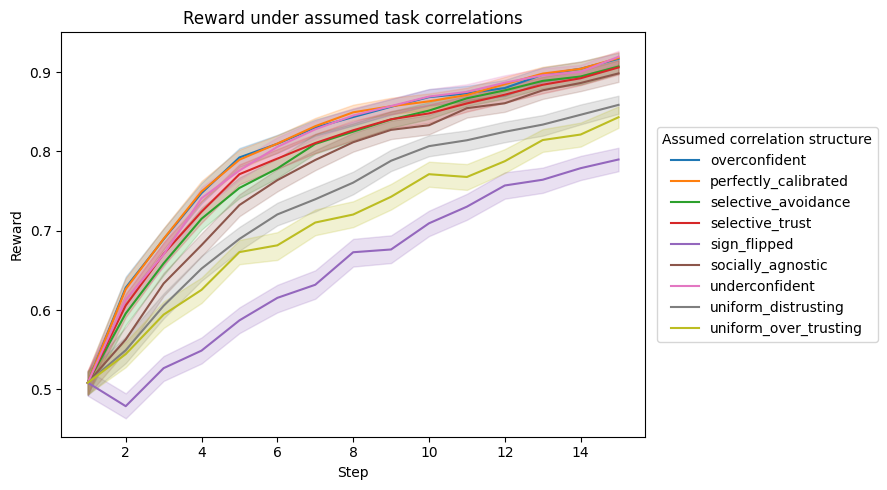

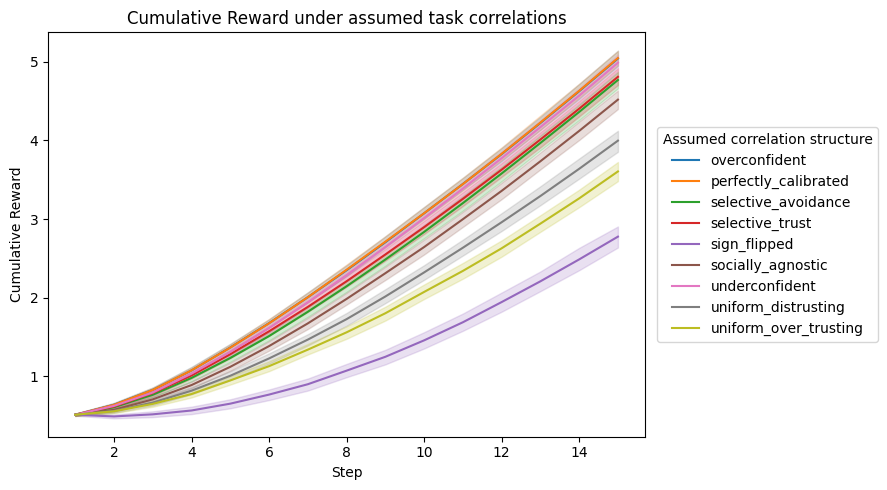

In [13]:
# All lines:
plot_reward(batch_results, y_col="reward")
plot_reward(batch_results, y_col="cumulative_reward")

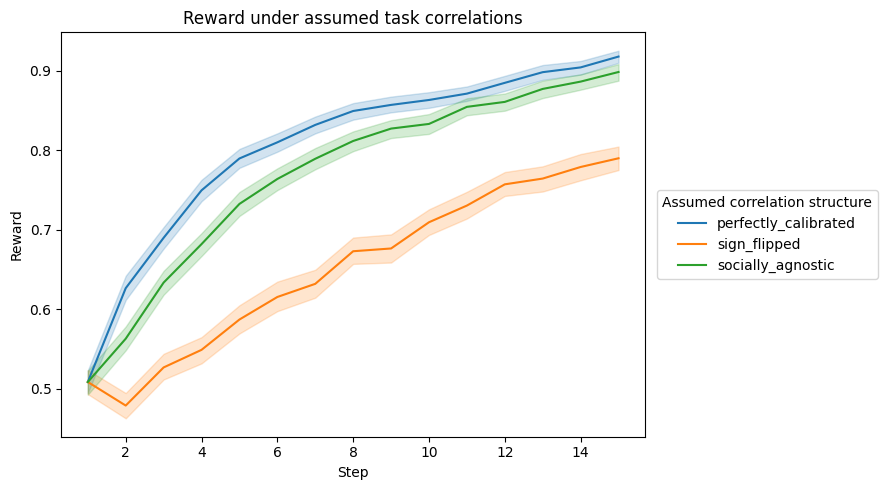

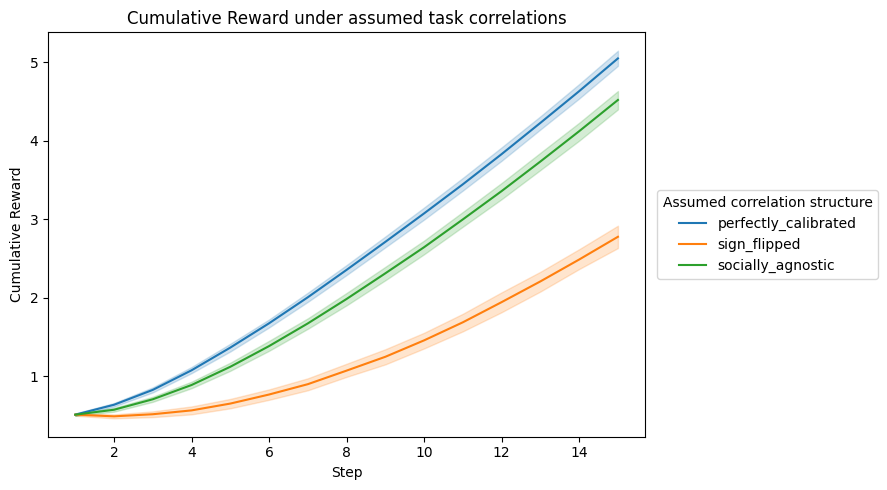

In [19]:
# Custom subset: 
my_subset = [
    "perfectly_calibrated",  # beliefs match the true environment
    "sign_flipped",          # trusts the anti-correlated peer and avoids the helpful one
    "socially_agnostic",     # ignores all social information
    ]
plot_reward(batch_results, y_col="reward", keep_labels=my_subset)
plot_reward(batch_results, y_col="cumulative_reward", keep_labels=my_subset)

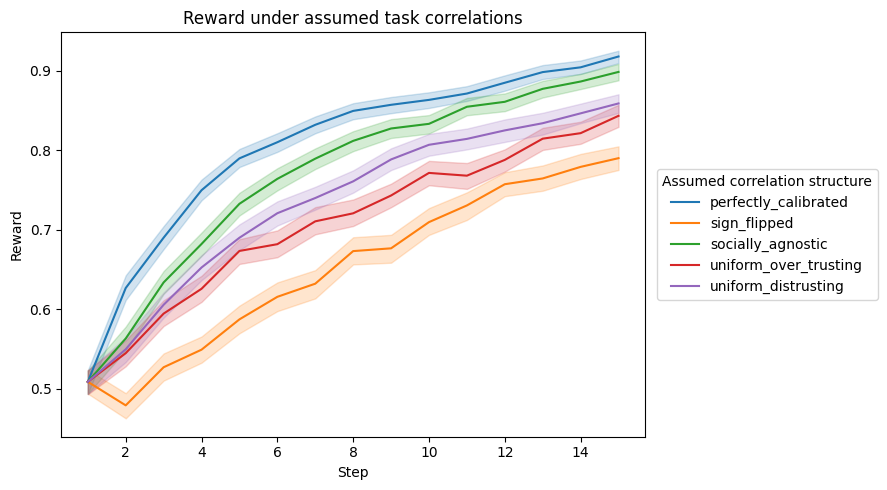

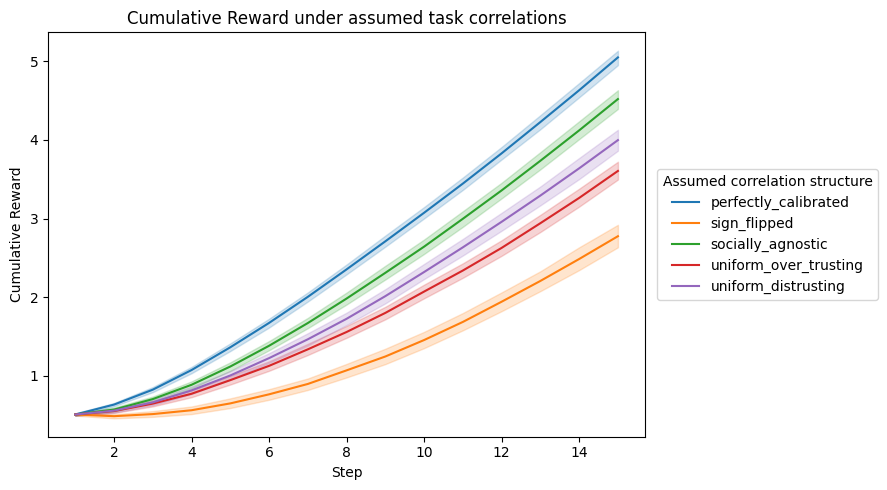

In [20]:
# Custom subset:
my_subset = [
    "perfectly_calibrated",  # beliefs match the true environment
    "sign_flipped",          # trusts the anti-correlated peer and avoids the helpful one
    "socially_agnostic",     # ignores all social information
    "uniform_over_trusting", # assumes everyone is positively aligned (over-generalization) 
    "uniform_distrusting"    # assumes everyone is anti-correlated (over-avoidance)
    ]
plot_reward(batch_results, y_col="reward", keep_labels=my_subset)
plot_reward(batch_results, y_col="cumulative_reward", keep_labels=my_subset)

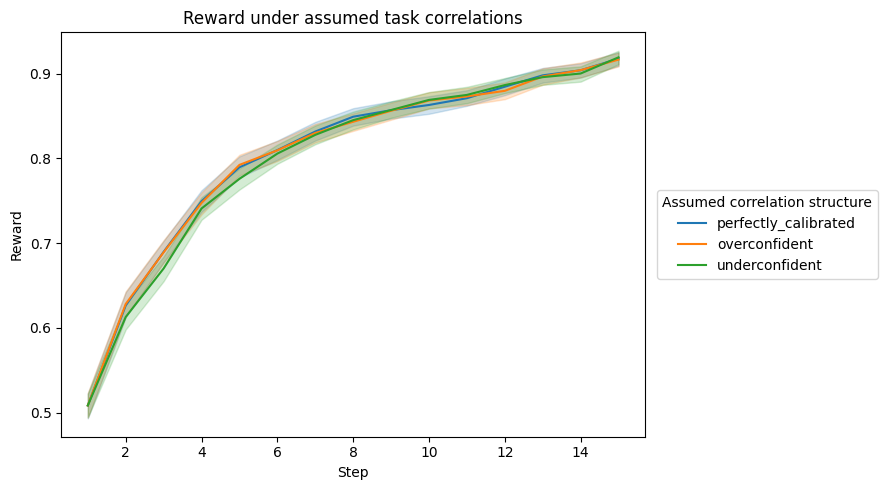

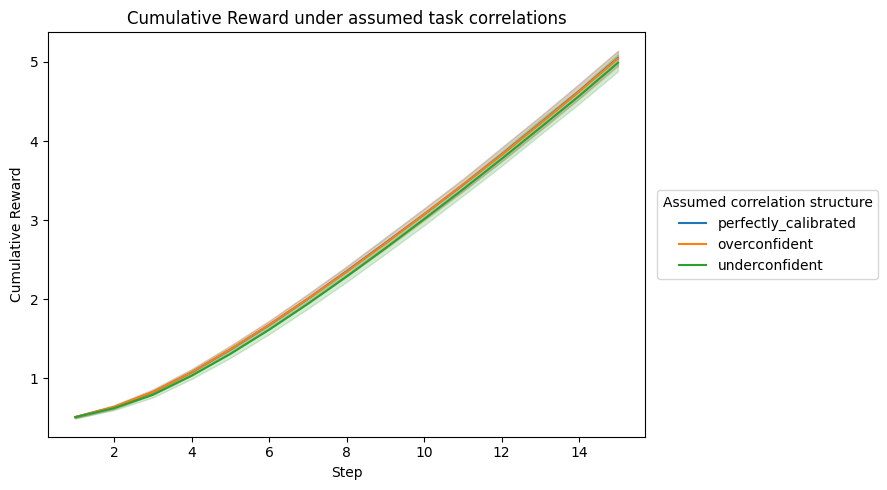

In [21]:
# Custom subset: knows who to trust or distrust, but the magnitude is not corect
my_subset = [
    "perfectly_calibrated",  # beliefs match the true environment
    "overconfident",          # right signs, inflated strength; tests sensitivity to overconfidence
    "underconfident",         # right signs, damped strength; tests robustness to weak beliefs
    ]
plot_reward(batch_results, y_col="reward", keep_labels=my_subset)
plot_reward(batch_results, y_col="cumulative_reward", keep_labels=my_subset)

# “aligned vs sign-flipped vs agnostic” to highlight correctness of belief.

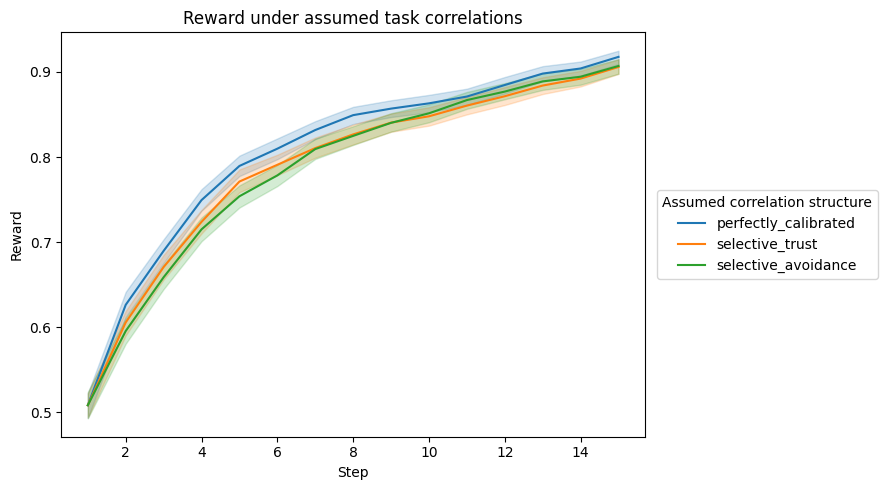

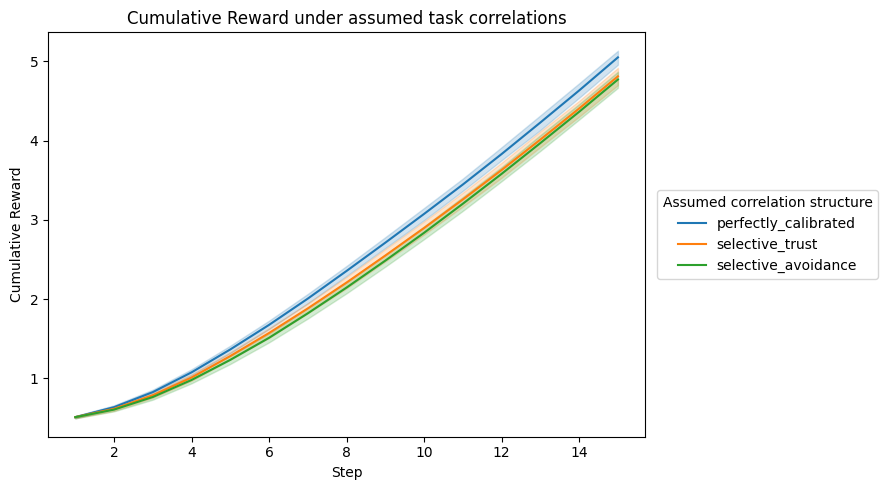

In [22]:
# Custom subset: [trust/distrust] the correct person, and ignore the one that should be [distrust/trust]
my_subset = [
    "perfectly_calibrated",  # beliefs match the true environment
    "selective_trust",        # trusts only the truly helpful peer; ignores the harmful one
    "selective_avoidance"    # avoids only the harmful peer; ignores the helpful one
    ]
plot_reward(batch_results, y_col="reward", keep_labels=my_subset)
plot_reward(batch_results, y_col="cumulative_reward", keep_labels=my_subset)

# “aligned vs sign-flipped vs agnostic” to highlight correctness of belief.